<a href="https://colab.research.google.com/github/Anthony253400/Projet_SDD_4/blob/main/dechet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Anthony253400/Projet_SDD_4

Cloning into 'Projet_SDD_4'...
remote: Enumerating objects: 2845, done.
remote: Total 2845 (delta 0), reused 0 (delta 0), pack-reused 2845 (from 3)
Receiving objects: 100% (2845/2845), 131.81 MiB | 14.03 MiB/s, done.
Resolving deltas: 100% (136/136), done.
Updating files: 100% (7633/7633), done.


In [ ]:
# lib
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import time
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

seed = 25
tf.keras.utils.set_random_seed(seed)


In [ ]:


base_path = f'/content/Projet_SDD_4/data'
img_height= 384
img_width = 512
batch_size = 32


train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/Projet_SDD_4/data/train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed = seed

)

val_data = tf.keras.utils.image_dataset_from_directory(
   '/content/Projet_SDD_4/data/val',
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = val_data.class_names
print(class_names)
print(train_data.class_names)


Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


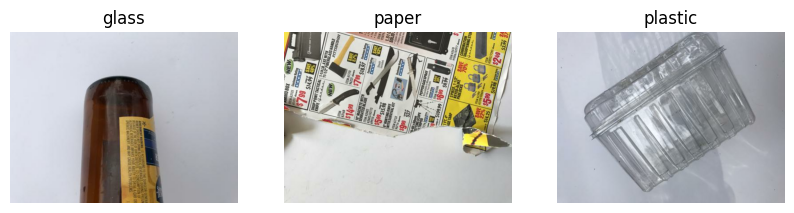

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

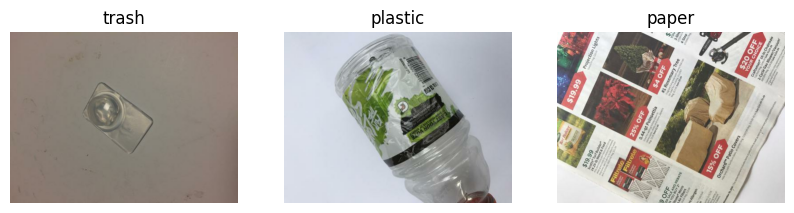

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in val_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
num_classes = 6
start_time_m1 = time.time()

model1 = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model1.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy'],)

callback_modele1 = tf.keras.callbacks.TensorBoard(log_dir="logs/model1")

model1.fit(
    train_data,
  validation_data=val_data,
  epochs=8,
    callbacks=[callback_modele1]
)

end_time_m1 = time.time()

Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.2850 - loss: 1.6688 - val_accuracy: 0.3993 - val_loss: 1.5351
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 725ms/step - accuracy: 0.4170 - loss: 1.4278 - val_accuracy: 0.5271 - val_loss: 1.2322
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 59s 742ms/step - accuracy: 0.5123 - loss: 1.2571 - val_accuracy: 0.5730 - val_loss: 1.0753
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 725ms/step - accuracy: 0.5209 - loss: 1.2036 - val_accuracy: 0.6324 - val_loss: 1.0182
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 719ms/step - accuracy: 0.6258 - loss: 0.9934 - val_accuracy: 0.7190 - val_loss: 0.7792
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 721ms/step - accuracy: 0.6978 - loss: 0.8288 - val_accuracy: 0.7432 - val_loss: 0.6761
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 723ms/step - accuracy: 0.7631 - loss: 0.6374 - val_accuracy: 0.8104 - val_loss: 0.5342
Epoch 8/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 57s 723ms/step - accuracy: 0.8230 - loss: 0.4958 - val_accuracy: 0.84

In [ ]:
num_classes = 6
start_time_m2 = time.time()

model2 = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model2.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy'],)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/model2")
model2.fit(
    train_data,
  validation_data=val_data,
  epochs=8,
    callbacks=[tensorboard_callback]
)
end_time_m2 = time.time()


Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 433ms/step - accuracy: 0.2182 - loss: 1.7766 - val_accuracy: 0.3843 - val_loss: 1.5300
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.4096 - loss: 1.4561 - val_accuracy: 0.4693 - val_loss: 1.3169
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - accuracy: 0.5083 - loss: 1.2656 - val_accuracy: 0.5402 - val_loss: 1.1948
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 208ms/step - accuracy: 0.5752 - loss: 1.1383 - val_accuracy: 0.6118 - val_loss: 1.0015
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.6206 - loss: 0.9903 - val_accuracy: 0.6854 - val_loss: 0.8052
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.6800 - loss: 0.8518 - val_accuracy: 0.7938 - val_loss: 0.6028
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.7586 - loss: 0.6817 - val_accuracy: 0.7998 - val_loss: 0.5810
Epoch 8/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7784 - loss: 0.5967 - val_accuracy: 0.

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 384, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 381, 509, 128)  │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 190, 254, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 187, 251, 64)   │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 93, 125, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 122, 32)    │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 45, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 42, 58, 16)     │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 21, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       623,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,407,460 (9.18 MB)

 Trainable params: 802,486 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,604,974 (6.12 MB)

In [ ]:
test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/Projet_SDD_4/data/test',
    image_size=(img_height, img_width),
    batch_size=batch_size
)
print("Modele 1 :")
results = model1.evaluate(test_data)
print("temp d'entrainement : "+str(end_time_m1 - start_time_m1) +" secondes")
print(f"Perte sur le test : {results[0]:.4f}")
print(f"Précision sur le test : {results[1]*100:.2f}%")

print("Modele 2 :")
results = model2.evaluate(test_data)
print("temp d'entrainement : "+str(end_time_m2 - start_time_m2) +" secondes")
print(f"Perte sur le test : {results[0]:.4f}")
print(f"Précision sur le test : {results[1]*100:.2f}%")

Found 2527 files belonging to 6 classes.
Modele 1 :
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8429 - loss: 0.4603
temp d'entrainement : 544.2577033042908 secondes
Perte sur le test : 0.4515
Précision sur le test : 84.84%
Modele 2 :
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8424 - loss: 0.4165
temp d'entrainement : 189.7940399646759 secondes
Perte sur le test : 0.4123
Précision sur le test : 84.84%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

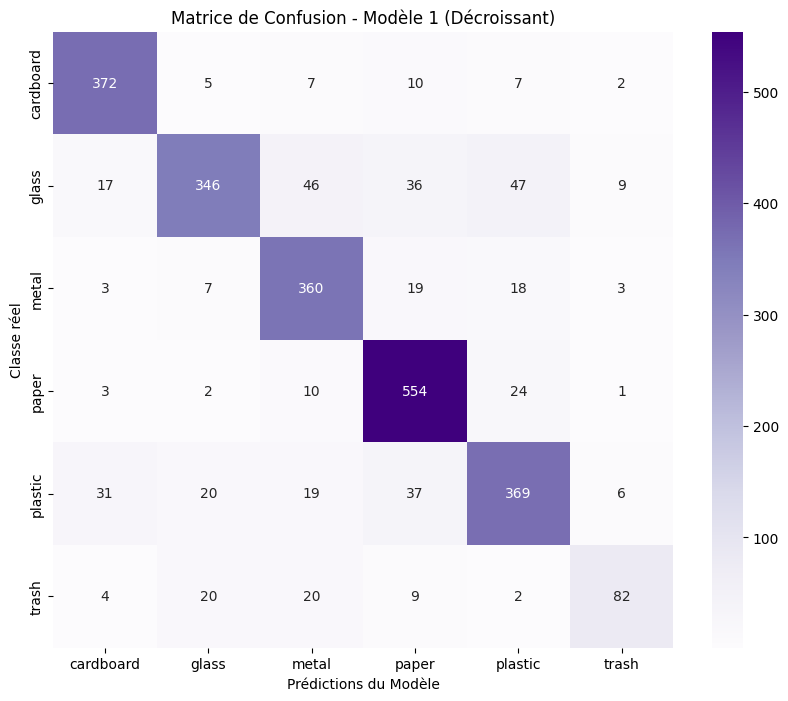

In [ ]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model1.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm1 = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Modèle 1 (Décroissant)')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

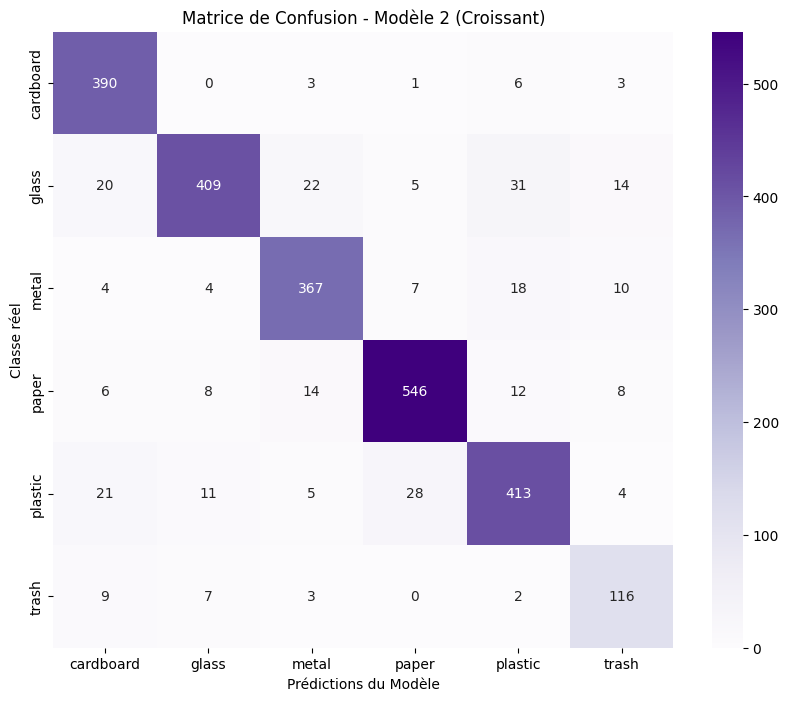

In [ ]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model2.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm1 = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Modèle 2 (Croissant)')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()

In [ ]:
model1.save('cnn1.keras')
model2.save('cnn2.keras')